In [ ]:
import plotly.express as plt
import matplotlib.pyplot as plt
import plotly.express as plt
import plotly.express as px
import pandas as pd
import seaborn as sns
import numpy as np




In [18]:
# Load the movie data
df = pd.read_csv("movies_cleaned.csv")

In [19]:
# Remove missing and invalid values
df = df.dropna(subset=["budget", "revenue"])
df = df[(df["budget"] > 0) & (df["revenue"] > 0)]

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


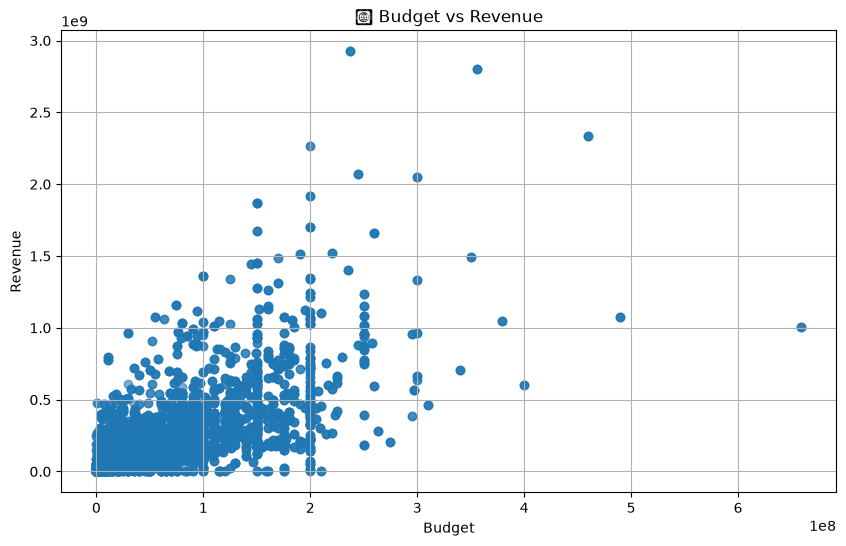

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))


plt.scatter(df["budget"], df["revenue"], alpha=0.6)

plt.title("💰 Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.grid(True)
plt.show()

In [28]:
# Load data
crew = pd.read_csv("crew_cleaned.csv")
Movies = pd.read_csv("movies_cleaned.csv")


In [30]:
# Merge datasets
df = crew.merge(movies, on="movie_id")


# Select Directors
df = df[df["job"] == "Director"]



In [32]:
# Find top 10 directors by revenue
result = df.groupby("person_name")["revenue"].sum()
result = result.sort_values(ascending=False).head(10)

# Convert revenue to millions
result = result / 1000000

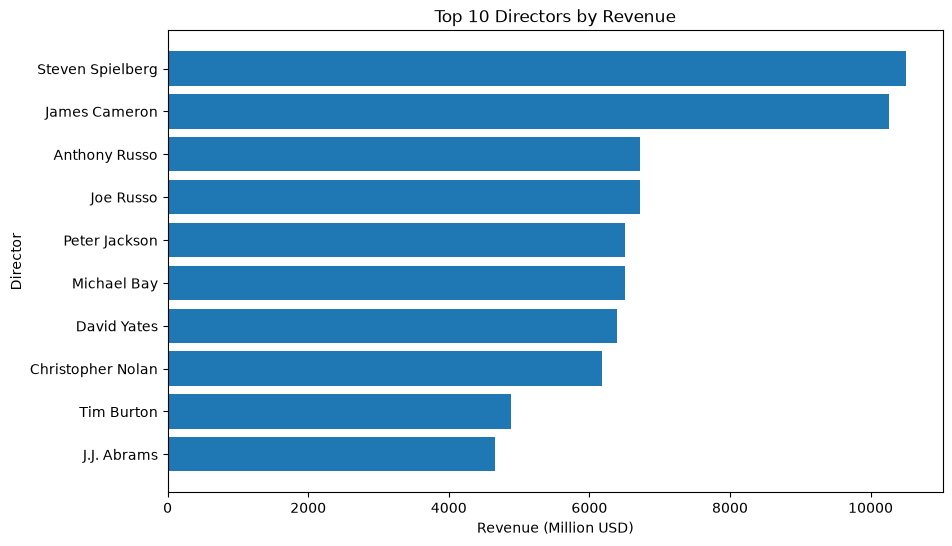

In [39]:
# Create chart
plt.figure(figsize=(10, 6))
plt.barh(result.index, result.values)

# Highest at top
plt.gca().invert_yaxis()

plt.title("Top 10 Directors by Revenue")
plt.xlabel("Revenue (Million USD)")
plt.ylabel("Director")

plt.show()

In [40]:
# Load data
keywords = pd.read_csv("movie_keywords_cleaned.csv")
movies = pd.read_csv("movies_cleaned.csv")

In [41]:
# Merge data
df = keywords.merge(movies, on="movie_id")


In [43]:
# Top 10 keywords by revenue
top10 = (
    df.groupby("keyword_name")["revenue"].sum()
    .sort_values(ascending=False).head(10))

# Keep only top 10 keywords
df = df[df["keyword_name"].isin(top10.index)]    

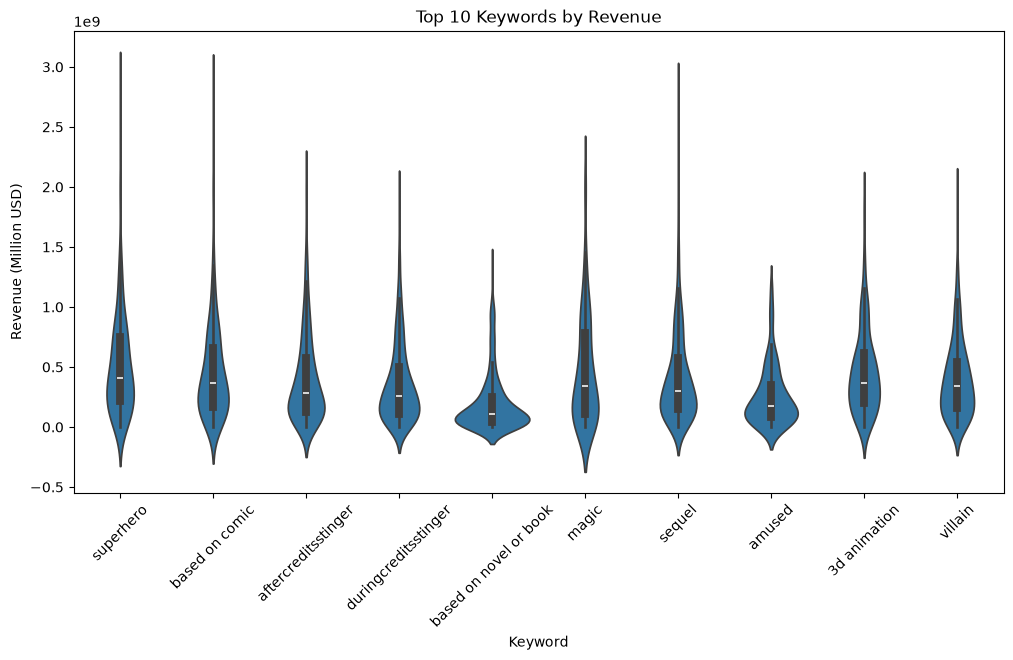

In [44]:
# Violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=df,x="keyword_name",y="revenue")
plt.xticks(rotation=45)
plt.title("Top 10 Keywords by Revenue")
plt.xlabel("Keyword")
plt.ylabel("Revenue (Million USD)")
plt.show()


In [49]:
# Load data
movies = pd.read_csv("movies_cleaned.csv")

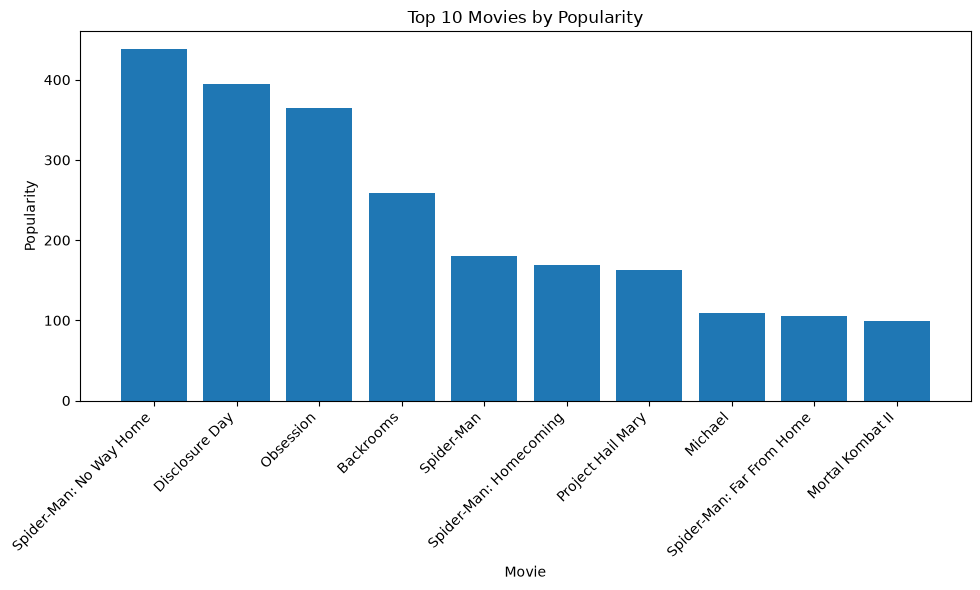

In [50]:
# Get top 10 popular movies
top10 = movies.sort_values("popularity", ascending=False).head(10)

# Bar chart
plt.figure(figsize=(10, 6))

plt.bar(top10["title"], top10["popularity"])

plt.title("Top 10 Movies by Popularity")
plt.xlabel("Movie")
plt.ylabel("Popularity")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [51]:
# Load data
movies = pd.read_csv("movies_cleaned.csv")
genres = pd.read_csv("genres_cleaned.csv")
movie_genres = pd.read_csv("movie_genres_cleaned.csv")

# Merge data
df = movie_genres.merge(genres, on="genre_id")
df = df.merge(movies, on="movie_id")


In [52]:
# Average rating by genre
result = df.groupby("genre_name")["vote_average"].mean()

# Sort highest to lowest
result = result.sort_values(ascending=False)

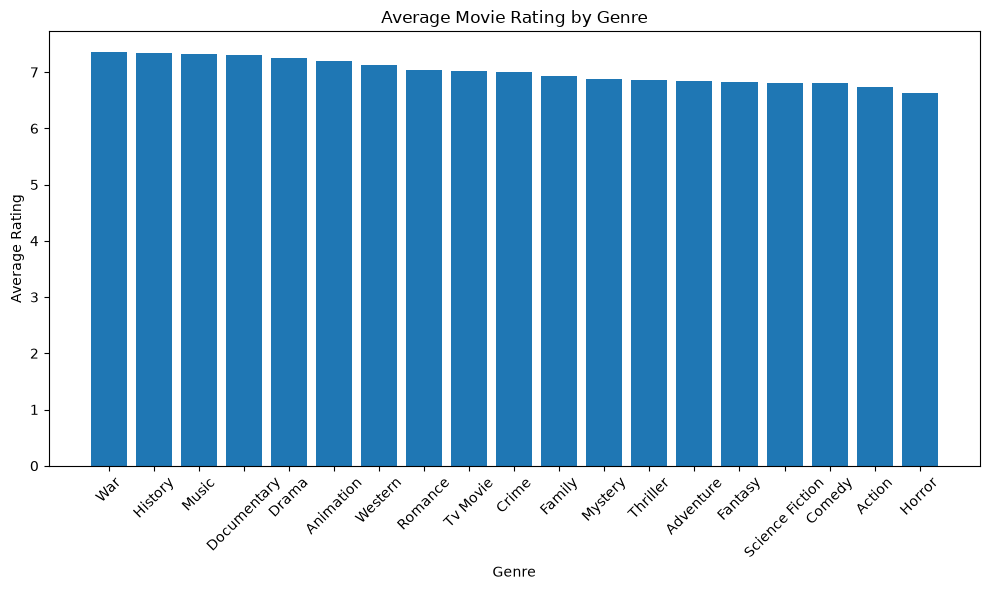

In [53]:
# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(result.index, result.values)

plt.title("Average Movie Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
# Load data
movies = pd.read_csv("movies_cleaned.csv")

# Remove missing and invalid values
df = movies.dropna(subset=["popularity", "vote_count"])
df = df[(df["popularity"] >= 0) & (df["vote_count"] >= 0)]

# Sort by popularity
df = df.sort_values("popularity", ascending=False)


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


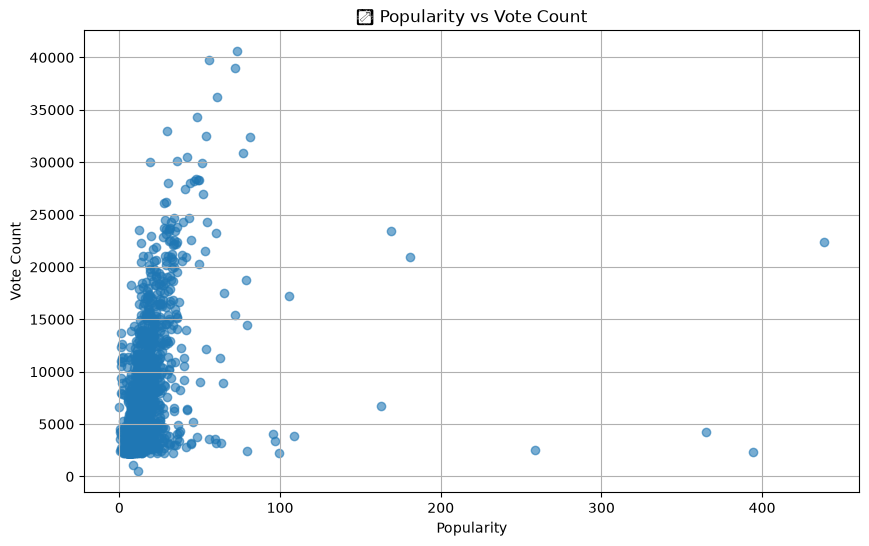

In [59]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df["popularity"], df["vote_count"], alpha=0.6)

plt.title("⭐ Popularity vs Vote Count")
plt.xlabel("Popularity")
plt.ylabel("Vote Count")

plt.grid(True)
plt.show()